In [ ]:
Phase 1: Project Setup & Getting the Data

In [1]:
import urllib.request
import os

# The URL for the IBM Telco Churn dataset (hosted on GitHub for easy access)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
file_path = "Telco-Customer-Churn.csv"

# Download the file
urllib.request.urlretrieve(url, file_path)
print(f"Successfully downloaded {file_path}!")

Successfully downloaded Telco-Customer-Churn.csv!


In [3]:
import os

# Check current working directory
print("Current working directory:", os.getcwd())

# List files in current directory
print("\nFiles in current directory:", os.listdir())

# List files in parent directory
print("\nFiles in parent directory:", os.listdir('..'))

Current working directory: F:\DS PROJECT

Files in current directory: ['.git', '.ipynb_checkpoints', '01_EDA_and_Preprocessing.ipynb.ipynb', 'data', 'Essentials.txt', 'notebooks', 'src', 'Telco-Customer-Churn.csv', 'Untitled.ipynb', 'venv']

Files in parent directory: ['$RECYCLE.BIN', '.GamingRoot', 'Airports and Ports Studies', 'Anaconda', 'archive.zip', 'Assetto-Corsa-SteamRIP.com.rar', 'Bengali Social Media Depressive Dataset (BSMDD)', 'Bengali Social Media Depressive Dataset (BSMDD).zip', 'chart1_subgroup_comparison.png', 'chart2_sgpt_distribution.png', 'chart3_correlation_heatmap.png', 'chart4_boxplots.png', 'chart5_engineered_features.png', 'Churn-Prediction', 'City Builder-saved.html', 'CKD Paper', 'CKD Ref Papers', 'CKD Ref Papers.zip', 'Cosmic Defender.html', 'CSV VLF', 'CSV VLF.zip', 'Data-Centric XR Research', 'Deep Learning for Tabular Fraud Detection', 'Deep Learning for Tabular Fraud Detection.zip', 'DL Tabular Project', 'DS FINAL PROJECT', 'DS MID PROJECT', 'DS MID PROJE

In [ ]:
Phase 2: The First Notebook (Exploratory Data Analysis)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for our charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the data
df = pd.read_csv('F:/DS PROJECT/Telco-Customer-Churn.csv')

# Display the first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# Check the shape of the data (rows, columns)
print(f"\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Check data types and missing values
print("\n--- Data Info ---")
df.info()

--- First 5 Rows ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Dataset Shape ---
Rows: 7043, Columns: 21

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for our charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the data
df = pd.read_csv('F:/DS PROJECT/Telco-Customer-Churn.csv')

# Display the first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# Check the shape of the data (rows, columns)
print(f"\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Check data types and missing values
print("\n--- Data Info ---")
df.info()

--- First 5 Rows ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Dataset Shape ---
Rows: 7043, Columns: 21

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   

In [ ]:
Phase 2: Data Cleaning & Initial Visualization

Missing values in TotalCharges after conversion: 11

OVERALL CHURN RATE: 26.54%

Churned customers: 1869 (26.54%)
Non-churned customers: 5174 (73.46%)


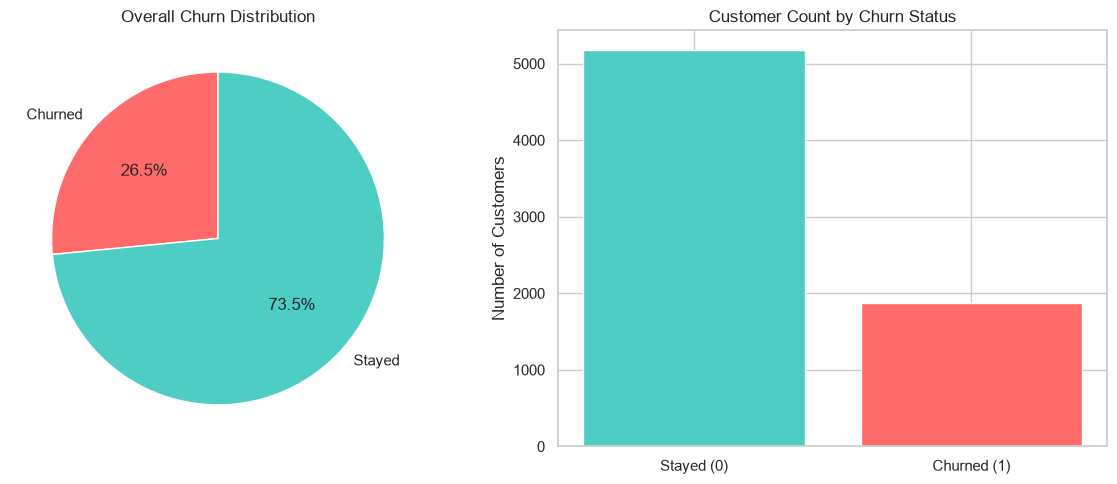

In [10]:
# ============================================
# DATA CLEANING
# ============================================

# Fix TotalCharges - convert to numeric (some values might be empty strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check if we created any NaN values
print(f"Missing values in TotalCharges after conversion: {df['TotalCharges'].isna().sum()}")

# Fill missing TotalCharges with 0 (likely new customers with no charges yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Convert Churn to binary: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ============================================
# INITIAL CHURN ANALYSIS
# ============================================

# Calculate overall churn rate
churn_rate = df['Churn'].mean()
print(f"\n{'='*50}")
print(f"OVERALL CHURN RATE: {churn_rate:.2%}")
print(f"{'='*50}")

# Count of churned vs non-churned customers
print(f"\nChurned customers: {df['Churn'].sum()} ({df['Churn'].sum()/len(df):.2%})")
print(f"Non-churned customers: {len(df) - df['Churn'].sum()} ({1-churn_rate:.2%})")

# ============================================
# VISUALIZATION: Churn Distribution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie([df['Churn'].sum(), len(df) - df['Churn'].sum()], 
            labels=['Churned', 'Stayed'], 
            autopct='%1.1f%%',
            colors=['#ff6b6b', '#4ecdc4'],
            startangle=90)
axes[0].set_title('Overall Churn Distribution')

# Bar chart
churn_counts = df['Churn'].value_counts()
axes[1].bar(['Stayed (0)', 'Churned (1)'], 
            [churn_counts[0], churn_counts[1]], 
            color=['#4ecdc4', '#ff6b6b'])
axes[1].set_title('Customer Count by Churn Status')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [ ]:
Phase 3: Preprocessing & Feature Engineering Code

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- SAFETY CHECK: Ensure TotalCharges is numeric (in case it wasn't caught earlier) ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# --- 1. Drop Irrelevant Data ---
# customerID is just a random identifier and has no predictive power
df_clean = df.drop(columns=['customerID'])

# --- 2. Feature Engineering ---
# Let's create a new feature: 'TenureGroup' to capture customer lifecycle stages
bins = [0, 12, 24, 48, 60, 72]
labels = ['0-12 Months', '13-24 Months', '25-48 Months', '49-60 Months', '61-72 Months']
df_clean['TenureGroup'] = pd.cut(df_clean['tenure'], bins=bins, labels=labels, right=True)

# --- 3. Encode Binary Categorical Variables (Yes/No, Male/Female) ---
# We map these to 0 and 1 so the model can read them
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col == 'gender':
        df_clean[col] = df_clean[col].map({'Male': 0, 'Female': 1})
    else:
        df_clean[col] = df_clean[col].map({'No': 0, 'Yes': 1})

# --- 4. One-Hot Encode Multi-class Categorical Variables ---
# This creates separate 0/1 columns for each category (e.g., InternetService_DSL, InternetService_Fiber optic)
# drop_first=True prevents the "dummy variable trap" (perfect multicollinearity)
df_encoded = pd.get_dummies(
    df_clean, 
    columns=[
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
        'Contract', 'PaymentMethod', 'TenureGroup'
    ], 
    drop_first=True, 
    dtype=int # Ensures the new columns are integers (0/1) not booleans (True/False)
)

# --- 5. Separate Features (X) and Target (y) ---
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# --- 6. Train / Test Split ---
# We hold out 20% of the data to test the model later. 
# stratify=y ensures our 26.5% churn rate is perfectly mirrored in both sets!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Preprocessing Complete!")
print(f"Total Features created: {X.shape[1]}")
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print(f"Churn rate in Training Set: {y_train.mean():.2%}")
print(f"Churn rate in Testing Set:  {y_test.mean():.2%}")

✅ Preprocessing Complete!
Total Features created: 34
Training set size: 5634 rows
Testing set size: 1409 rows
Churn rate in Training Set: 26.54%
Churn rate in Testing Set:  26.54%


In [ ]:
Phase 4: Modeling & Evaluation

Training models... (this may take a few seconds)


C:\Users\MN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



📊 Logistic Regression Evaluation


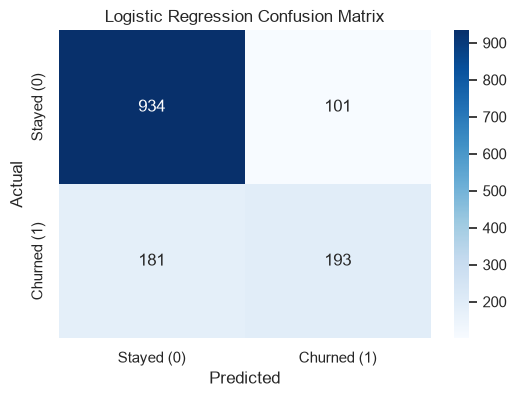


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

🎯 ROC-AUC Score: 0.8427 (1.0 is perfect, 0.5 is random guessing)

📊 XGBoost Evaluation


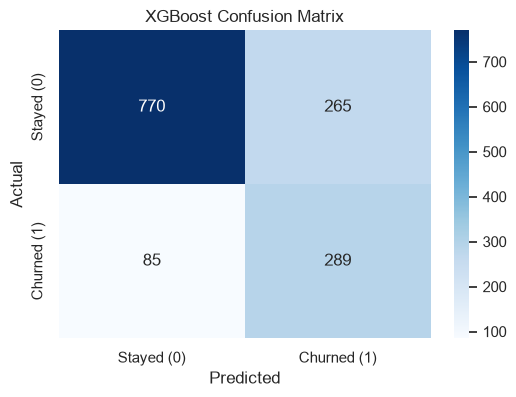


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

🎯 ROC-AUC Score: 0.8396 (1.0 is perfect, 0.5 is random guessing)


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Training models... (this may take a few seconds)")

# ============================================
# 1. BASELINE MODEL: Logistic Regression
# ============================================
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Get predictions and probabilities
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# ============================================
# 2. ADVANCED MODEL: XGBoost
# ============================================
# scale_pos_weight helps the model pay more attention to the minority class (churners)
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Get predictions and probabilities
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# ============================================
# 3. EVALUATION FUNCTION
# ============================================
def evaluate_model(y_true, y_pred, y_probs, model_name):
    print(f"\n{'='*40}")
    print(f"📊 {model_name} Evaluation")
    print(f"{'='*40}")
    
    # 1. Confusion Matrix Visualization
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Stayed (0)', 'Churned (1)'], 
                yticklabels=['Stayed (0)', 'Churned (1)'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    # 2. Classification Report (Precision, Recall, F1-Score)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    # 3. ROC-AUC Score
    roc_auc = roc_auc_score(y_true, y_probs)
    print(f"🎯 ROC-AUC Score: {roc_auc:.4f} (1.0 is perfect, 0.5 is random guessing)")

# Run the evaluation for both models
evaluate_model(y_test, lr_preds, lr_probs, "Logistic Regression")
evaluate_model(y_test, xgb_preds, xgb_probs, "XGBoost")

In [ ]:
Phase 5: Explainability

C:\Users\MN\AppData\Local\Temp\ipykernel_20208\2504534701.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


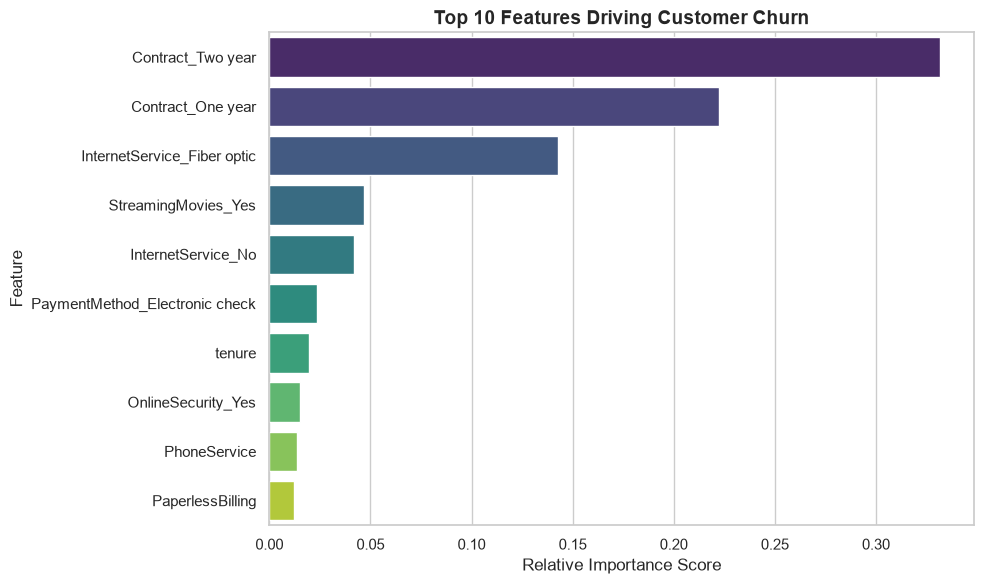

--- Top 3 Churn Drivers ---
1. Contract_Two year
1. Contract_One year
1. InternetService_Fiber optic


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the importance scores from our trained XGBoost model
importances = xgb_model.feature_importances_
feature_names = X_train.columns

# 2. Create a DataFrame to easily sort and view the data
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. Sort by importance and grab the top 10 drivers of churn
top_10_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 4. Visualize it!
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title('Top 10 Features Driving Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Print the top 3 for a quick summary
print("--- Top 3 Churn Drivers ---")
for i, row in top_10_features.head(3).iterrows():
    print(f"1. {row['Feature']}")